In [1]:
import sys
print(sys.executable)

c:\Users\rohit\OneDrive\Desktop\Personal Project\credit-risk-decision-engine\.venv\Scripts\python.exe


In [2]:
import pandas, lightgbm, shap, matplotlib, seaborn
print("all imports OK")

all imports OK


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_style("whitegrid")

In [6]:
DATA_PROCESSED = Path("../data/processed")

In [7]:
df = pd.read_parquet(DATA_PROCESSED / "application_train.parquet")
print(f"Loaded: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.4f}")

Loaded: (307511, 123)
Default rate: 0.0807


In [8]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AGE_YEARS']

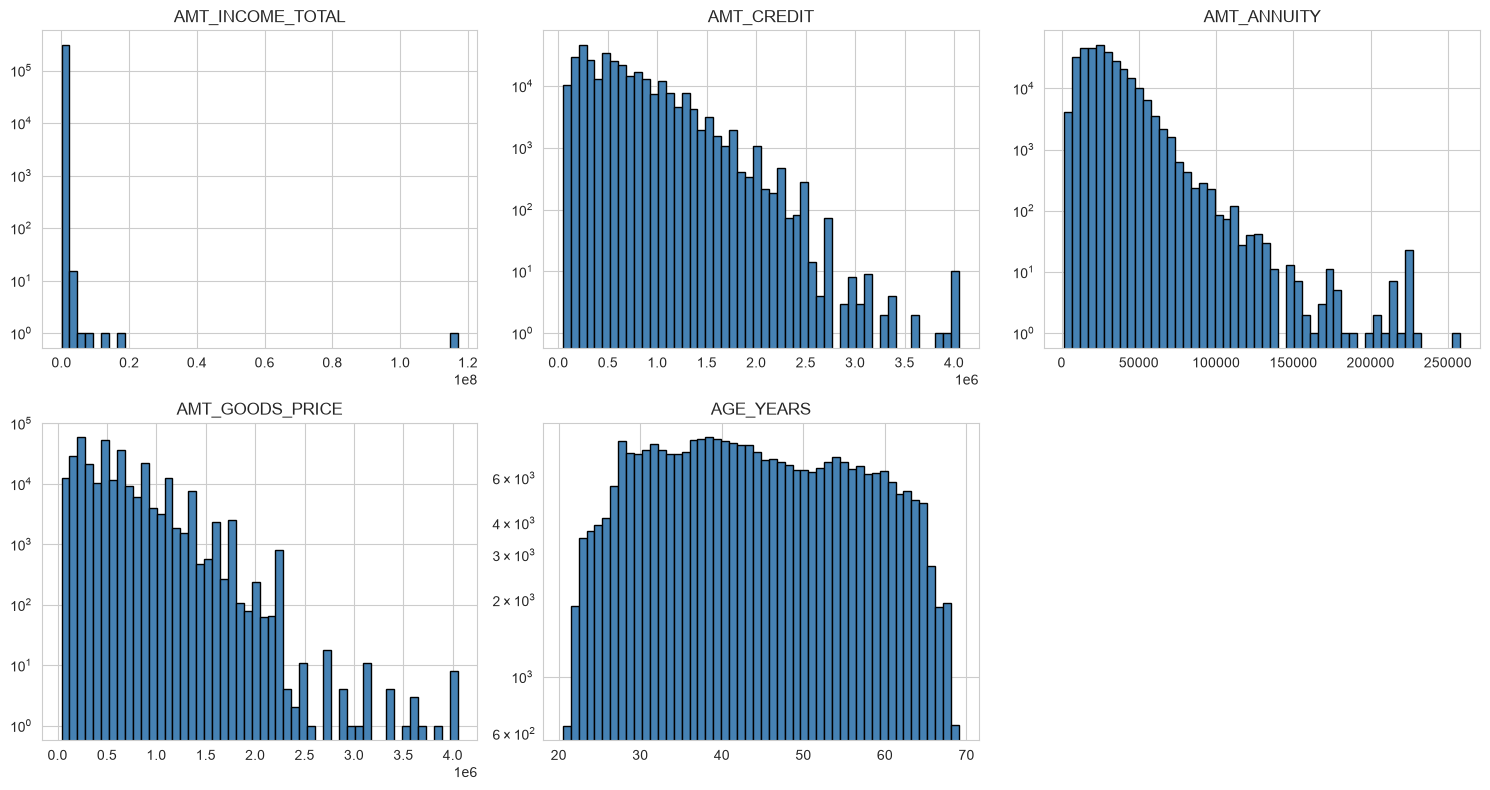

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_yscale('log')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

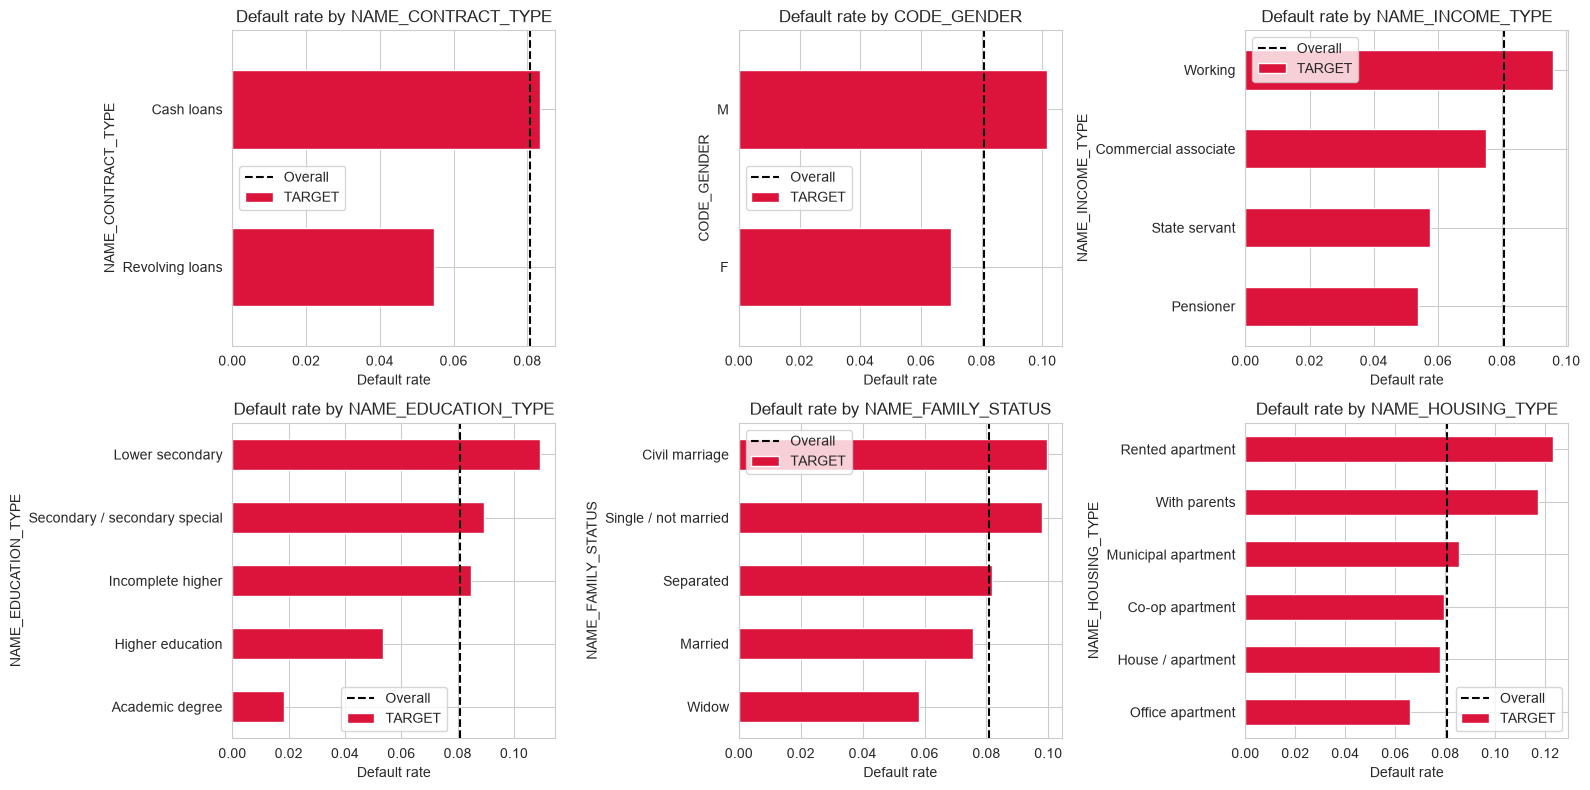

In [14]:
cat_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    valid_cats = counts[counts > 100].index
    default_rate = df.groupby(col)['TARGET'].mean()
    default_rate = default_rate[default_rate.index.isin(valid_cats)].sort_values()

    default_rate.plot(kind='barh', ax=axes[i], color='crimson')
    axes[i].set_title(f'Default rate by {col}')
    axes[i].set_xlabel('Default rate')
    axes[i].axvline(df['TARGET'].mean(), color='black', linestyle='--', label='Overall')
    axes[i].legend()
plt.tight_layout()
plt.show()

In [19]:
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corrwith(df['TARGET']).abs().sort_values(ascending=False)

print("Top 20 numeric features by |correlation| with TARGET:")
print(corr_with_target.head(20).round(4))

Top 20 numeric features by |correlation| with TARGET:
TARGET                         1.0000
EXT_SOURCE_3                   0.1789
EXT_SOURCE_2                   0.1605
EXT_SOURCE_1                   0.1553
DAYS_BIRTH                     0.0782
AGE_YEARS                      0.0782
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                  0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                  0.0440
FLOORSMAX_MEDI                 0.0438
FLOORSMAX_MODE                 0.0432
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE                0.0396
dtype: float64


In [ ]:
df_sorted = df.sort_values('SK_ID_CURR').reset_index(drop=True)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.902806
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.900068
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [27]:
n = len(df_sorted)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

In [22]:
train = df_sorted.iloc[:train_end].copy()
val   = df_sorted.iloc[train_end:val_end].copy()
test  = df_sorted.iloc[val_end:].copy()

print(f"Train: {train.shape}, default rate: {train['TARGET'].mean():.4f}")
print(f"Val:   {val.shape}, default rate: {val['TARGET'].mean():.4f}")
print(f"Test:  {test.shape}, default rate: {test['TARGET'].mean():.4f}")

Train: (215257, 123), default rate: 0.0813
Val:   (46127, 123), default rate: 0.0798
Test:  (46127, 123), default rate: 0.0792


In [24]:
for name, split in [('train', train), ('val', val), ('test', test)]:
    path = DATA_PROCESSED / f"{name}.parquet"
    split.to_parquet(path, index=False)
    print(f"Saved {path} ({split.shape})")

Saved ..\data\processed\train.parquet ((215257, 123))
Saved ..\data\processed\val.parquet ((46127, 123))
Saved ..\data\processed\test.parquet ((46127, 123))


In [29]:
print((df['AMT_INCOME_TOTAL'] > 10_000_000).sum())

3
